In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.nn.utils.rnn import pad_sequence

# ✅ Set device (CUDA if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# 📌 New base path to manually split features
base_path = "/content/drive/MyDrive/features"

# 📌 Load filenames directly from split folders
real_train = sorted(os.listdir(os.path.join(base_path, "train/real")))
fake_train = sorted(os.listdir(os.path.join(base_path, "train/fake")))

real_val = sorted(os.listdir(os.path.join(base_path, "validate/real")))
fake_val = sorted(os.listdir(os.path.join(base_path, "validate/fake")))

real_test = sorted(os.listdir(os.path.join(base_path, "test/real")))
fake_test = sorted(os.listdir(os.path.join(base_path, "test/fake")))

# ✅ Print dataset sizes
print(f"Training: {len(real_train)} real, {len(fake_train)} fake")
print(f"Validation: {len(real_val)} real, {len(fake_val)} fake")
print(f"Testing: {len(real_test)} real, {len(fake_test)} fake")

# 📌 Custom Dataset Class
class DeepFakeDataset(Dataset):
    def __init__(self, video_list, label, base_path):
        self.video_list = video_list
        self.label = label
        self.base_path = base_path

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_name = self.video_list[idx]
        feature_path = os.path.join(self.base_path, video_name)

        if os.path.exists(feature_path) and os.path.getsize(feature_path) > 0:
            features = np.load(feature_path)
        else:
            print(f"❌ Error: File not found or empty: {feature_path}")
            features = np.zeros((1, 1792), dtype=np.float32)

        if features.shape[-1] != 1792:
            print(f"⚠️ Warning: {video_name} has incorrect shape {features.shape}. Reshaping...")
            features = features.reshape(-1, 1792)

        return torch.tensor(features, dtype=torch.float32), torch.tensor(self.label, dtype=torch.long)

# ✅ Create Datasets using new paths
train_dataset = ConcatDataset([
    DeepFakeDataset(real_train, 0, os.path.join(base_path, "train/real")),
    DeepFakeDataset(fake_train, 1, os.path.join(base_path, "train/fake"))
])

val_dataset = ConcatDataset([
    DeepFakeDataset(real_val, 0, os.path.join(base_path, "validate/real")),
    DeepFakeDataset(fake_val, 1, os.path.join(base_path, "validate/fake"))
])

test_dataset = ConcatDataset([
    DeepFakeDataset(real_test, 0, os.path.join(base_path, "test/real")),
    DeepFakeDataset(fake_test, 1, os.path.join(base_path, "test/fake"))
])

# 📌 Custom Collate Function (Pads sequences to same length)
def custom_collate_fn(batch):
    features = [item[0].squeeze(0) for item in batch]
    labels = [item[1] for item in batch]

    features_padded = pad_sequence(features, batch_first=True, padding_value=0)
    features_padded = features_padded.view(features_padded.shape[0], -1, 1792)

    labels = torch.stack(labels)
    return features_padded, labels

# ✅ Create DataLoaders with dynamic batch size
try:
    batch_size = 16
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
    print("Data Loading Complete 🚀")
except RuntimeError as e:
    print("⚠️ CUDA OOM Error: Reducing batch size to 4")
    batch_size = 8
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)


Using Device: cuda
Training: 216 real, 1839 fake
Validation: 72 real, 613 fake
Testing: 75 real, 616 fake
Data Loading Complete 🚀


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

# 📌 Define Attention Mechanism
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, lstm_out):
        attn_weights = self.softmax(self.attn(lstm_out))
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return context

# 📌 Define DeepFakeModel
class DeepFakeModel(nn.Module):
    def __init__(self):
        super(DeepFakeModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1792, hidden_size=512, num_layers=1, batch_first=True)
        self.attention = Attention(512)
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out = self.attention(lstm_out)
        return self.fc(attn_out)

# ✅ Device and model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepFakeModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)  # 📉 Decay LR every 10 epochs

In [3]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 4,724,227


📅 Epoch 1/150 | 🔁 Loss: 44.2815 | 🎯 Train Acc: 0.8949 | ✅ Val Acc: 0.8949
📅 Epoch 2/150 | 🔁 Loss: 34.3827 | 🎯 Train Acc: 0.9124 | ✅ Val Acc: 0.9168
📅 Epoch 3/150 | 🔁 Loss: 27.6305 | 🎯 Train Acc: 0.9178 | ✅ Val Acc: 0.9182
📅 Epoch 4/150 | 🔁 Loss: 25.2086 | 🎯 Train Acc: 0.9333 | ✅ Val Acc: 0.9474
📅 Epoch 5/150 | 🔁 Loss: 18.6419 | 🎯 Train Acc: 0.9479 | ✅ Val Acc: 0.9139
📅 Epoch 6/150 | 🔁 Loss: 22.3886 | 🎯 Train Acc: 0.9387 | ✅ Val Acc: 0.8861
📅 Epoch 7/150 | 🔁 Loss: 17.0300 | 🎯 Train Acc: 0.9509 | ✅ Val Acc: 0.9328
📅 Epoch 8/150 | 🔁 Loss: 16.1426 | 🎯 Train Acc: 0.9557 | ✅ Val Acc: 0.9387
📅 Epoch 9/150 | 🔁 Loss: 15.7646 | 🎯 Train Acc: 0.9572 | ✅ Val Acc: 0.9270
📅 Epoch 10/150 | 🔁 Loss: 14.8884 | 🎯 Train Acc: 0.9586 | ✅ Val Acc: 0.9401
📅 Epoch 11/150 | 🔁 Loss: 10.7240 | 🎯 Train Acc: 0.9674 | ✅ Val Acc: 0.9533
📅 Epoch 12/150 | 🔁 Loss: 10.0203 | 🎯 Train Acc: 0.9703 | ✅ Val Acc: 0.9504
📅 Epoch 13/150 | 🔁 Loss: 9.9445 | 🎯 Train Acc: 0.9703 | ✅ Val Acc: 0.9504
📅 Epoch 14/150 | 🔁 Loss: 9.1332 | 🎯

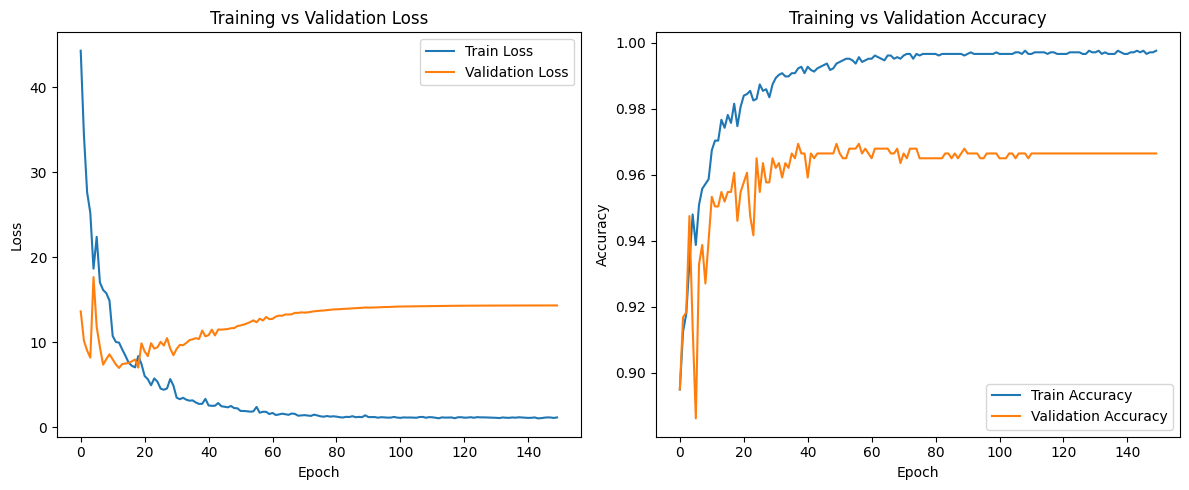

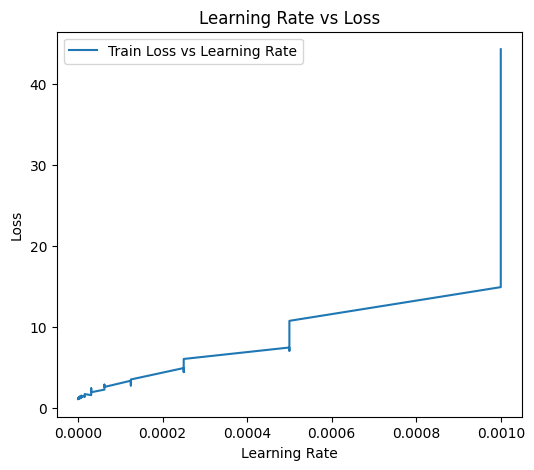

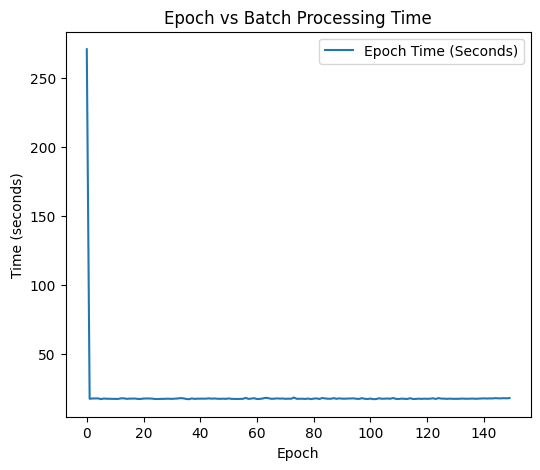

🏁 Training Completed!


In [ ]:
import time
import matplotlib.pyplot as plt

# Lists to store metrics for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []
epoch_times = []

# ✅ Training & Validation Loop
num_epochs = 150
best_val_acc = 0.0
best_model_state_dict = None  # Track the best model's state dict

for epoch in range(num_epochs):
    start_time = time.time()  # Track time for the epoch

    model.train()
    total_loss, correct, total = 0, 0, 0

    # Learning rate schedule (if you are using one)
    learning_rate = optimizer.param_groups[0]['lr']
    learning_rates.append(learning_rate)

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        try:
            loss.backward()
            optimizer.step()
        except RuntimeError:
            print("⚠️ CUDA OOM Error: Skipping this batch...")
            continue

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ✅ Validation inside epoch
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"📅 Epoch {epoch+1}/{num_epochs} | 🔁 Loss: {total_loss:.4f} | 🎯 Train Acc: {train_acc:.4f} | ✅ Val Acc: {val_acc:.4f}")

    # Save losses and accuracies for plotting
    train_losses.append(total_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict()  # Save the best model state_dict

    scheduler.step()  # Learning rate scheduler (if applicable)

    # Calculate epoch time
    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

# After training is complete, save the best model
if best_model_state_dict is not None:
    torch.save(best_model_state_dict, "/content/drive/MyDrive/100 epochs/best_model.pth")
    print("📦 Best Model Saved after Training Completion!")

# ✅ Load Best Model for Final Evaluation
model.load_state_dict(torch.load("/content/drive/MyDrive/100 epochs/best_model.pth"))

# Plotting Training vs Validation Loss/Accuracy
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("/content/drive/MyDrive/100 epochs/training graphs/training_vs_validation_loss.png")  # Save the plot as PNG

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("/content/drive/MyDrive/100 epochs/training graphs/training_vs_validation_accuracy.png")  # Save the plot as PNG

plt.tight_layout()
plt.show()

# Plot Learning Rate vs Loss (During training, per epoch)
plt.figure(figsize=(6, 5))
plt.plot(learning_rates, train_losses, label='Train Loss vs Learning Rate')
plt.title('Learning Rate vs Loss')
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.legend()
plt.savefig("/content/drive/MyDrive/100 epochs/training graphs/learning_rate_vs_loss.png")  # Save the plot as PNG
plt.show()

# Plot Epoch vs Batch Processing Time
plt.figure(figsize=(6, 5))
plt.plot(range(num_epochs), epoch_times, label='Epoch Time (Seconds)')
plt.title('Epoch vs Batch Processing Time')
plt.xlabel('Epoch')
plt.ylabel('Time (seconds)')
plt.legend()
plt.savefig("/content/drive/MyDrive/100 epochs/training graphs/epoch_vs_batch_time.png")  # Save the plot as PNG
plt.show()

print("🏁 Training Completed!")


✅ Test Accuracy: 96.24%

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.92      0.72      0.81        75
        Fake       0.97      0.99      0.98       616

    accuracy                           0.96       691
   macro avg       0.94      0.86      0.89       691
weighted avg       0.96      0.96      0.96       691


🧩 Confusion Matrix:
[[ 54  21]
 [  5 611]]


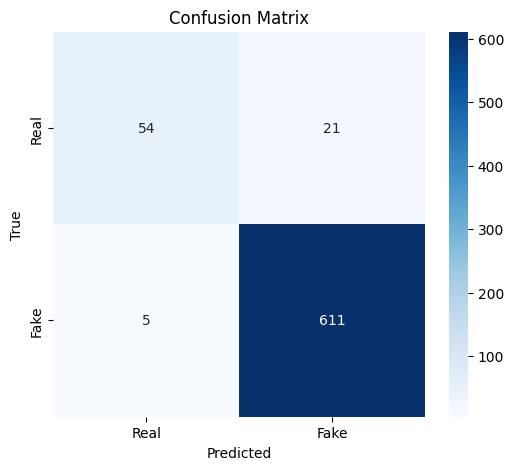

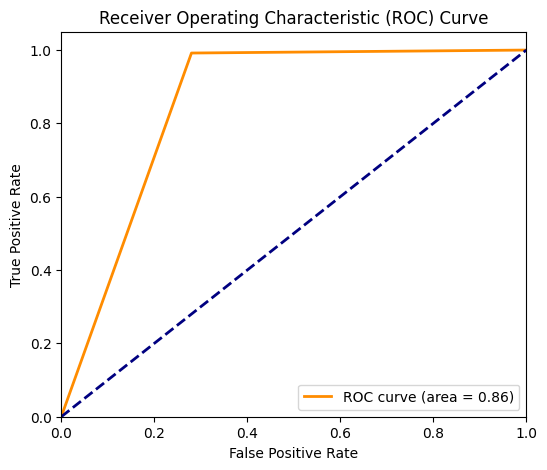

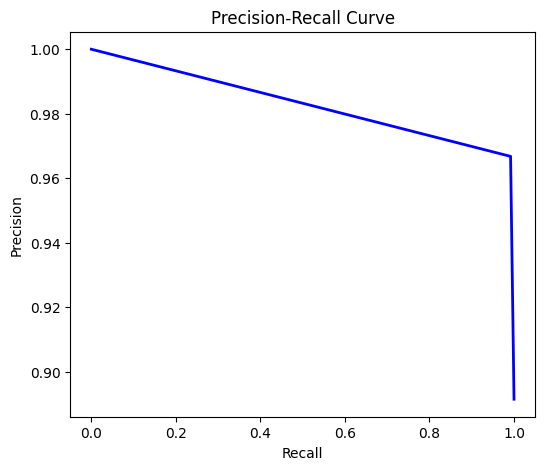

📊 Final Accuracy: 96.24%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# 📌 Evaluation on Test Set
def evaluate_model(model, test_loader):
    correct, total = 0, 0
    all_predictions, all_labels = [], []

    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total * 100
    print(f"✅ Test Accuracy: {accuracy:.2f}%")
    return all_predictions, all_labels

# 🔍 Run Evaluation
predictions, true_labels = evaluate_model(model, test_loader)

# 📊 Classification Report
print("\n📊 Classification Report:")
print(classification_report(true_labels, predictions, target_names=["Real", "Fake"]))

# 🧩 Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
print("\n🧩 Confusion Matrix:")
print(cm)

# 🔍 Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("/content/drive/MyDrive/100 epochs/testing/confusion_matrix.png")  # Save confusion matrix plot
plt.show()

# 🧩 Plot ROC Curve
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("/content/drive/MyDrive/100 epochs/testing/roc_curve.png")  # Save ROC curve plot
plt.show()

# 🧩 Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_labels, predictions)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.savefig("/content/drive/MyDrive/100 epochs/testing/precision_recall_curve.png")  # Save precision-recall curve plot
plt.show()

# 📊 Accuracy Plot (Optional)
accuracy_per_batch = [1 if p == t else 0 for p, t in zip(predictions, true_labels)]
accuracy_plot = sum(accuracy_per_batch) / len(accuracy_per_batch) * 100

print(f"📊 Final Accuracy: {accuracy_plot:.2f}%")

# Plot Accuracy over time if applicable
# This can be done by plotting the accuracy across test batches (optional)


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/100 epochs/deepfake_model_state_dict.pth')  # Save only the model's weights


In [ ]:
import numpy as np

data = np.load('filename.npy')
print(data)
